# Exploratory Data Analysis - NYC Yellow Taxi Trips

## Dataset
NYC Yellow Taxi Trip Records - May 2022

## Objective
Perform an exploratory data analysis to understand the structure,
quality, distributions, and relationships within the taxi trip dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
root = Path.cwd()

if not (root / "pyproject.toml").exists():
    root = root.parent

data_path = root / "data" / "raw" / "yellow_tripdata_2022-05.parquet"

df = pd.read_parquet(data_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 3,588,295
Columns: 19


In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


## 1. Initial Dataset Inspection

In [4]:
df.shape

(3588295, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3588295 entries, 0 to 3588294
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3588295.0,1.713103,1.0,1.0,2.0,2.0,6.0,0.488809
tpep_pickup_datetime,3588295,2022-05-16 07:50:29.219312,2003-01-01 00:06:06,2022-05-08 18:14:16.500000,2022-05-16 09:14:42,2022-05-23 18:03:17,2022-06-01 23:55:30,NaN
tpep_dropoff_datetime,3588295,2022-05-16 08:08:42.275203,2003-01-01 00:31:38,2022-05-08 18:32:36,2022-05-16 09:33:15,2022-05-23 18:21:03.500000,2022-06-02 00:03:51,NaN
passenger_count,3458771.0,1.393923,0.0,1.0,1.0,1.0,9.0,0.955549
trip_distance,3588295.0,6.856861,0.0,1.15,1.96,3.73,357192.65,690.848782
RatecodeID,3458771.0,1.365674,1.0,1.0,1.0,1.0,99.0,5.239789
PULocationID,3588295.0,164.573797,1.0,132.0,162.0,234.0,265.0,65.628132
DOLocationID,3588295.0,162.551711,1.0,113.0,162.0,234.0,265.0,70.279259
payment_type,3588295.0,1.183209,0.0,1.0,1.0,1.0,4.0,0.507599
fare_amount,3588295.0,15.168132,-1311.5,7.0,10.5,17.0,6966.5,14.89484


In [7]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

In [8]:
##Missing values

missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": (df.isnull().mean() * 100).round(2)
}).sort_values("Percent", ascending=False)

missing

,Missing,Percent
store_and_fwd_flag,129524,3.61
RatecodeID,129524,3.61
passenger_count,129524,3.61
airport_fee,129524,3.61
congestion_surcharge,129524,3.61
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
DOLocationID,0,0.00
PULocationID,0,0.00


In [9]:
#Duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# 2 Data Quality Assessment

In [10]:
missing[missing["Missing"] > 0]

,Missing,Percent
store_and_fwd_flag,129524,3.61
RatecodeID,129524,3.61
passenger_count,129524,3.61
airport_fee,129524,3.61
congestion_surcharge,129524,3.61


In [11]:
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


VendorID
VendorID
2    2527997
1    1054130
6       6154
5         14
Name: count, dtype: int64

RatecodeID
RatecodeID
1.0     3256985
2.0      147239
NaN      129524
5.0       28382
3.0       11636
99.0       9864
4.0        4626
6.0          39
Name: count, dtype: int64

store_and_fwd_flag
store_and_fwd_flag
N      3404113
NaN     129524
Y        54658
Name: count, dtype: int64

payment_type
payment_type
1    2720127
2     706333
0     129524
3      16333
4      15978
Name: count, dtype: int64


In [12]:
# Valores negativos

numeric_check = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "airport_fee"
]

negative_values = df[numeric_check].lt(0).sum().sort_values(ascending=False)

negative_values


total_amount             20709
improvement_surcharge    20663
fare_amount              20506
mta_tax                  19970
congestion_surcharge     16487
extra                     9917
airport_fee               2301
tolls_amount               925
tip_amount                 237
trip_distance                0
passenger_count              0
dtype: int64

In [13]:
# Valores 0

zero_values = df[numeric_check].eq(0).sum().sort_values(ascending=False)

zero_values

tolls_amount             3291553
airport_fee              3175153
extra                    1478115
tip_amount                857270
congestion_surcharge      267509
passenger_count            73587
trip_distance              46438
mta_tax                    38227
fare_amount                 1498
improvement_surcharge       1376
total_amount                 534
dtype: int64

In [14]:
print(df["tpep_pickup_datetime"].min())
print(df["tpep_pickup_datetime"].max())

print(df["tpep_dropoff_datetime"].min())
print(df["tpep_dropoff_datetime"].max())

2003-01-01 00:06:06
2022-06-01 23:55:30
2003-01-01 00:31:38
2022-06-02 00:03:51


In [15]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration_minutes"].describe()

count    3.588295e+06
mean     1.821760e+01
std      5.156663e+01
min     -1.408333e+01
25%      7.666667e+00
50%      1.270000e+01
75%      2.061667e+01
max      6.823550e+03
Name: trip_duration_minutes, dtype: float64

In [ ]:
# Viajes con duración inválida

print("Duration <= 0:", (df["trip_duration_minutes"] <= 0).sum())

Duration <= 0: 3030


In [ ]:
#Valores extremos

df[[
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes"
]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
trip_distance,3588295.0,6.856861,690.848782,0.000000,0.000000,0.50,1.96,16.00,20.30,357192.65
fare_amount,3588295.0,15.168132,14.894840,-1311.500000,2.500000,4.50,10.50,52.00,63.00,6966.50
total_amount,3588295.0,22.078401,18.486835,-1314.800000,5.550000,8.80,16.30,63.41,81.36,6970.80
trip_duration_minutes,3588295.0,18.217598,51.566625,-14.083333,0.383333,3.35,12.70,43.95,71.45,6823.55


# 3. Exploratory Analysis

In [18]:
#sample 

eda_sample = df.sample(n=min(200_000, len(df)), random_state=42)

eda_sample.shape

(200000, 20)

### Trip Distance Distribution

We analyze the distribution of taxi trip distances and identify the most common travel ranges.

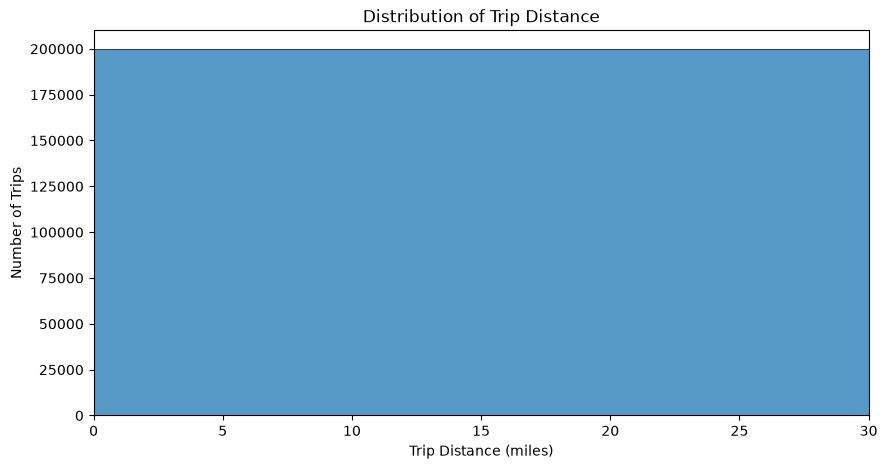

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    eda_sample["trip_distance"],
    bins=100
)

plt.xlim(0, 30)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")
plt.show()

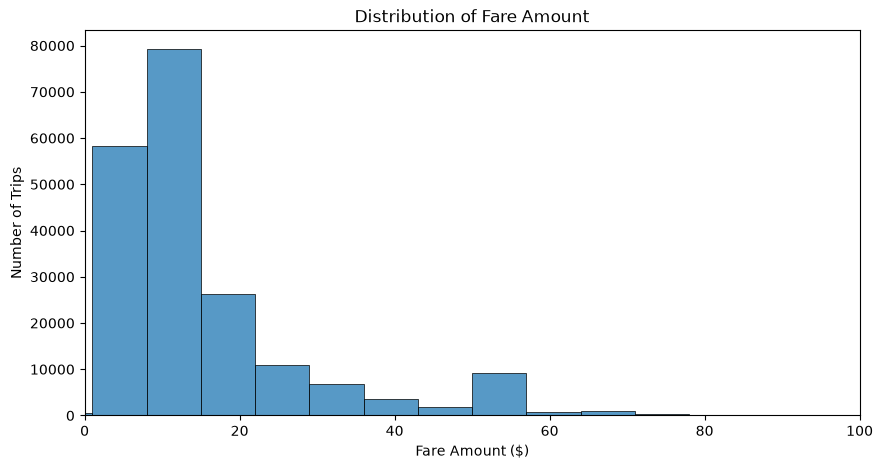

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    eda_sample["fare_amount"],
    bins=100
)

plt.xlim(0, 100)
plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Fare Amount")
plt.show()

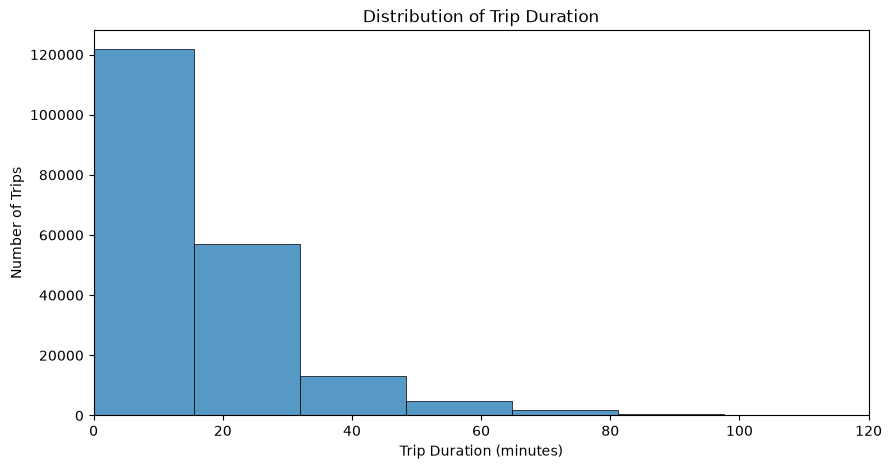

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    eda_sample["trip_duration_minutes"],
    bins=100
)

plt.xlim(0, 120)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Duration")
plt.show()

## 4. Temporal Analysis

We examine taxi demand according to hour of the day and day of the week.

In [23]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.day_name()

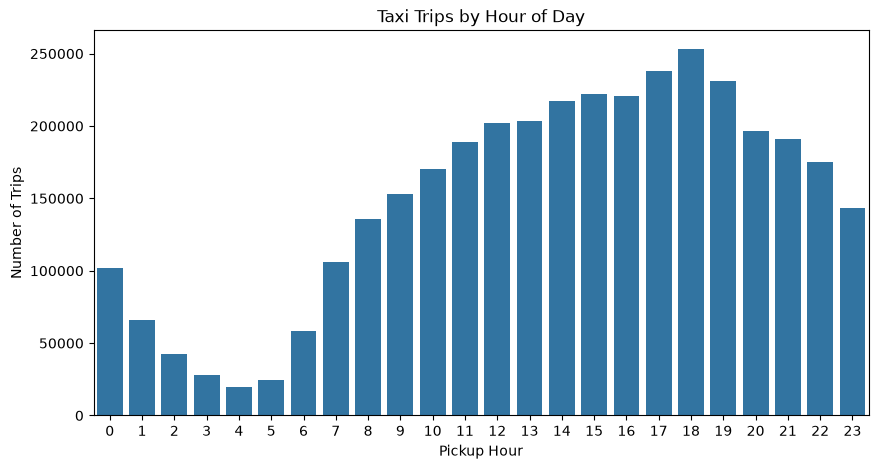

In [24]:
hourly_trips = df["pickup_hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=hourly_trips.index,
    y=hourly_trips.values
)

plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.title("Taxi Trips by Hour of Day")
plt.show()

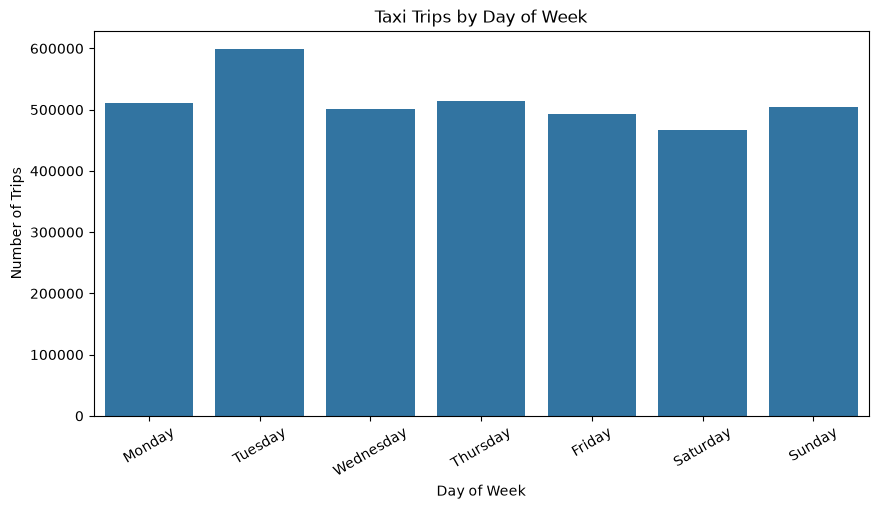

In [25]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_trips = (
    df["pickup_dayofweek"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=daily_trips.index,
    y=daily_trips.values
)

plt.xticks(rotation=30)
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("Taxi Trips by Day of Week")
plt.show()

# 5. Relationship Analysis

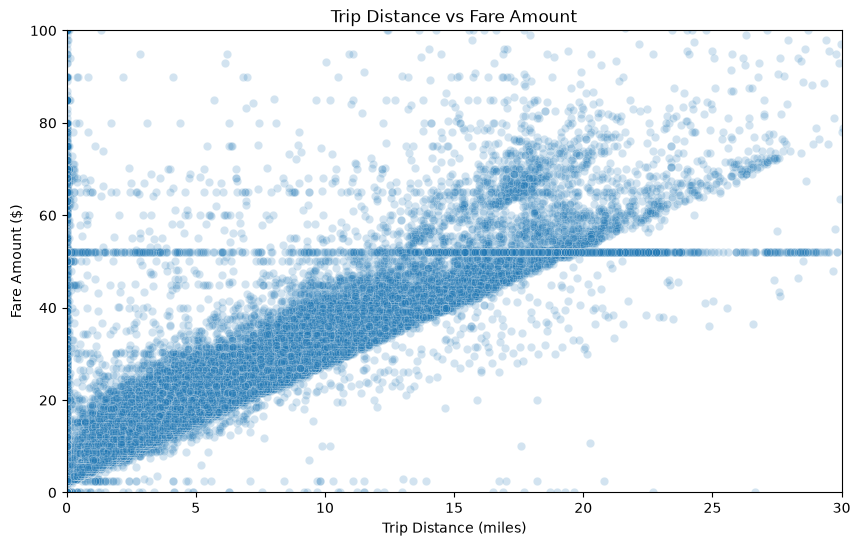

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="trip_distance",
    y="fare_amount",
    alpha=0.2
)

plt.xlim(0, 30)
plt.ylim(0, 100)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Trip Distance vs Fare Amount")
plt.show()

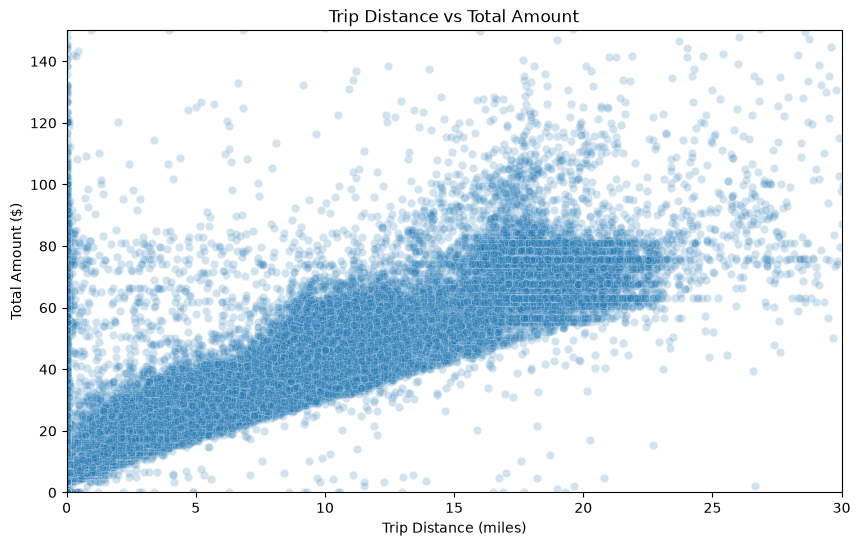

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="trip_distance",
    y="total_amount",
    alpha=0.2
)

plt.xlim(0, 30)
plt.ylim(0, 150)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Total Amount ($)")
plt.title("Trip Distance vs Total Amount")
plt.show()

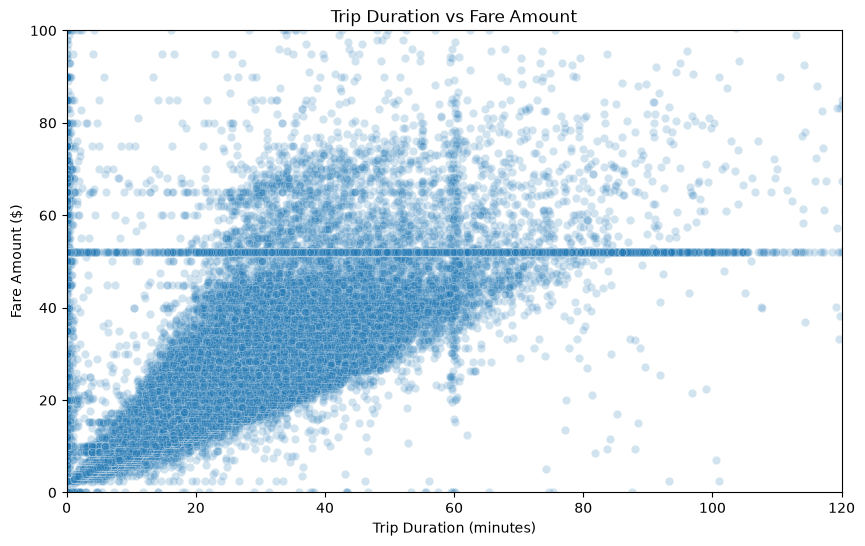

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="trip_duration_minutes",
    y="fare_amount",
    alpha=0.2
)

plt.xlim(0, 120)
plt.ylim(0, 100)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount ($)")
plt.title("Trip Duration vs Fare Amount")
plt.show()

## 6. Correlation Analysis

We examine the relationships between the main numerical variables in the dataset.

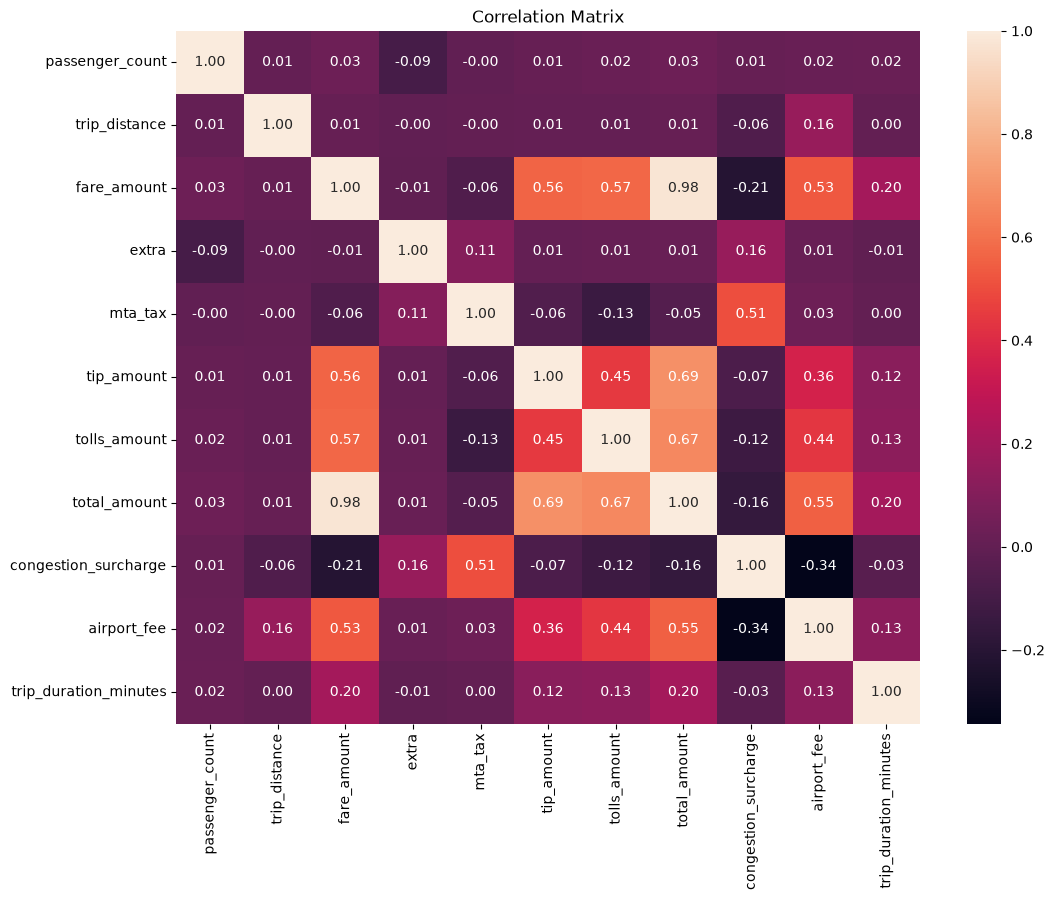

In [29]:
corr_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "congestion_surcharge",
    "airport_fee",
    "trip_duration_minutes"
]

correlation = df[corr_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# 7. Outlier Analysis

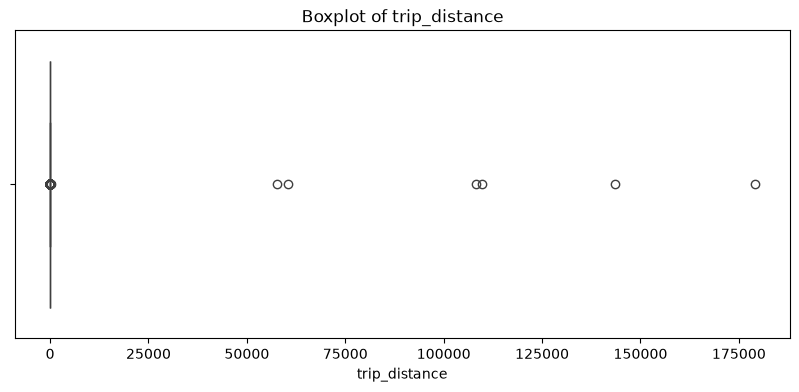

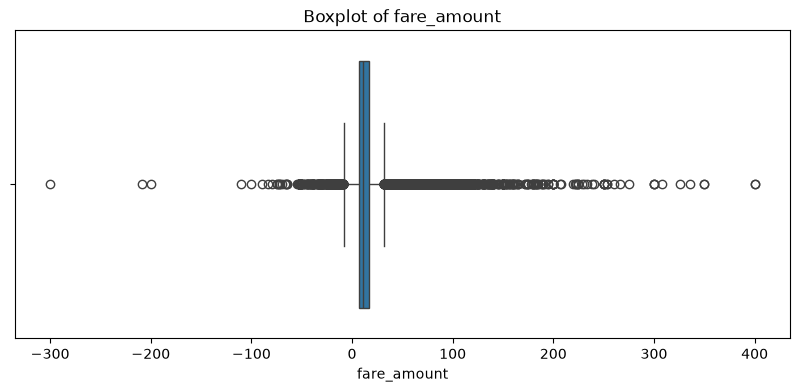

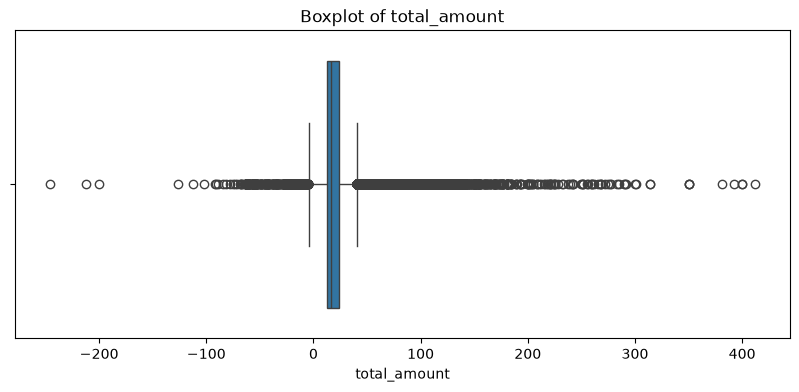

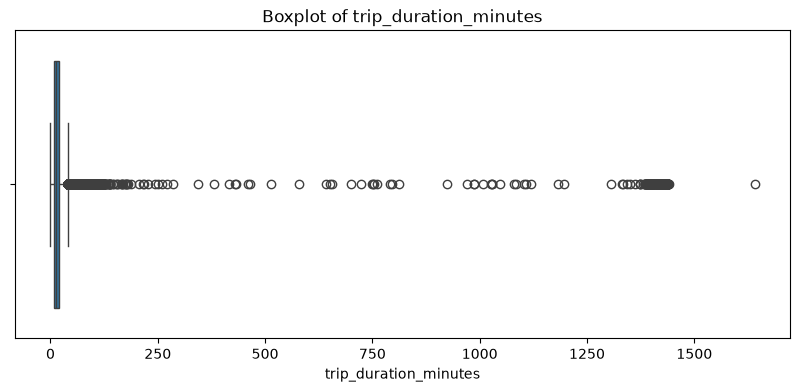

In [30]:
outlier_cols = [
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes"
]

for col in outlier_cols:
    plt.figure(figsize=(10, 4))
    
    sns.boxplot(x=eda_sample[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

# 8. Top Pickup and Dropoff Locations

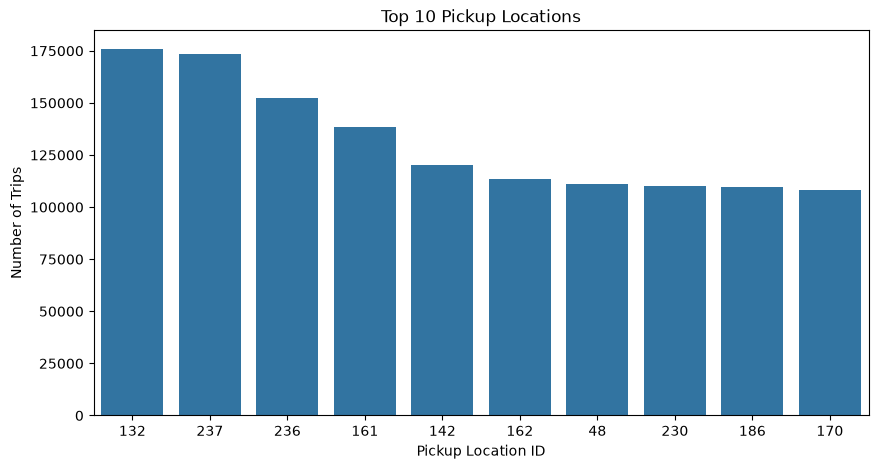

In [31]:
top_pickups = df["PULocationID"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_pickups.index.astype(str),
    y=top_pickups.values
)

plt.xlabel("Pickup Location ID")
plt.ylabel("Number of Trips")
plt.title("Top 10 Pickup Locations")
plt.show()

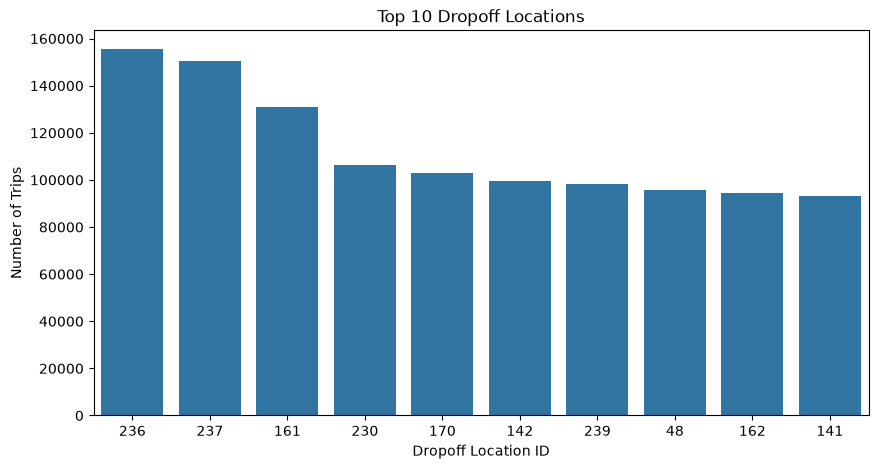

In [32]:
top_dropoffs = df["DOLocationID"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_dropoffs.index.astype(str),
    y=top_dropoffs.values
)

plt.xlabel("Dropoff Location ID")
plt.ylabel("Number of Trips")
plt.title("Top 10 Dropoff Locations")
plt.show()

## 9. Main Findings

The exploratory data analysis provided several relevant insights into the NYC Yellow Taxi trips dataset for May 2022.

### Data Quality
- The dataset contains missing values in several variables.
- Duplicate records were checked.
- Several numerical variables contain zero or negative values that require attention during the data preparation stage.
- Trip duration was derived from pickup and dropoff timestamps.

### Trip Characteristics
- Trip distance, fare amount, total amount, and trip duration show highly asymmetric distributions.
- Most taxi trips are concentrated within relatively short distances and durations.
- Extreme values are present and should be considered during subsequent preprocessing.

### Temporal Patterns
- The number of trips varies considerably depending on the pickup hour.
- Taxi activity also changes across the days of the week.

### Relationships
- Trip distance has a relationship with fare amount and total amount.
- Trip duration also shows a relationship with fare amount.
- The correlation matrix reveals relationships between the main numerical variables.

### Spatial Patterns
- A relatively small number of pickup and dropoff location IDs account for a large portion of the observed trips.

### Conclusion
The EDA provides an initial understanding of the dataset and identifies important data quality issues, distributions, temporal patterns, and relationships that should be considered before model development.